In [1]:
import random
import numpy as np
import os
from os import path
import time
import copy
import torch
from torch import nn
from gan_training.utils4nb import return_data_test
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from gan_training import utils
from gan_training.train import Trainer, update_average
from gan_training.logger import Logger
from gan_training.checkpoints import CheckpointIO
from gan_training.inputs import get_dataset
from gan_training.distributions import get_ydist, get_zdist
from gan_training.eval_test import DisentEvaluator, Evaluator
from gan_training.config4nb import (
    load_config, build_models, build_optimizers, build_lr_scheduler,
)


C:\Users\Rashmi\Anaconda\envs\torch-gpu\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# Arguments

#args.config_dir='./configs'
config='cells_650.yaml'
VAEname= 'FactorVAE3'
#VAEname='BetaVAE_H'
chkptname= 'last'
config_dir='./configs'
output_dir= './outputs/'
#dvae_name= None
                   


In [3]:
#LC-136
#CellCycle-
#CPA-176-
#EMT-164-
#LiveCell -157


config_path = os.path.join(config_dir, config)
config = load_config(config_path)

nf=-1 #Base number of filters


bs=1 #'Batch size'
reg_param=-1 #'R1 regularization parameter'
w_info =-1#'weighting constant on ID Loss')
mi=max_iter=-1 #'Max training iteration')
num_workers=0 #'dataloader num_workers'
#batch_size=32 # help='batch size'

image_size= 256         #  Image size
dset_dir='./ProcessedData/'
datatype='rgb'
nc= 3

#parser.add_argument('--img_size', default=128, type=int, help='Image synthesis size')##This is the image size for which the autoencoder is designed to


c_dim= 10 #Latent synthesis size'
z_dim=256 #type=int, help='Image synthesis size')

no_cuda=False #help='Do not use cuda')
seed=1 #type=int, help='Random Seed')
infodistil_mode=True #'Infodistill')
#args = parser.parse_args()

#dvae_name='cells_trial_factor176' 
#name='GAN_Trial176_1'
TrainDataset='LC-136' # Example LC, EMT, CPA
TestDataset='LC/'
Model_dir='./Models'
dset_dir='./ProcessedData/'
#config_path = os.path.join(config_dir, config)
is_cuda = (torch.cuda.is_available() and not no_cuda)


In [4]:
VAE_chkptname='last'
GAN_chkptname='model.pt'
data_dir=os.path.join(dset_dir,TestDataset)
#out_dir = os.path.join(output_dir, name)
fvae_ckpt_path = os.path.join(Model_dir, TrainDataset, 'VAE','chkpts',VAE_chkptname)
gan_ckpt_path = os.path.join(Model_dir, TrainDataset, 'GAN','chkpts')
     


In [5]:

# Logger
checkpoint_io = CheckpointIO(
    checkpoint_dir=gan_ckpt_path
)

device = torch.device("cuda:0" if is_cuda else "cpu")

train_dataset = get_dataset(
    name='image',
    data_dir=data_dir,
    size=image_size,
)
train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=bs,
        num_workers=3,
        shuffle=True, pin_memory=True, sampler=None, drop_last=True
)



In [6]:
device = torch.device("cuda:0" if is_cuda else "cpu")
device

device(type='cuda', index=0)

In [7]:


#Create models
fvae, generator, discriminator = build_models(image_size, c_dim, nc, z_dim)
data_loader = return_data_test(TestDataset, datatype, dset_dir, bs, image_size)



In [8]:
selectVAE='fvae'

if selectVAE=='dvae':
    dvae_ckpt_path =  os.path.join()

    dvae_ckpt = torch.load(dvae_ckpt_path)
    #for key in list(dvae_ckpt_path.keys()):
    #    dvae_ckpt_path[key.replace('decoder.', 'module.decoder.'). replace('encoder.', 'module.encoder.')] = dvae_ckpt_path.pop(key)

    dvae.load_state_dict(dvae_ckpt_path)
else:

    #fvae_ckpt_path = os.path.join(output_dir, dvae_name,'chkpts', chkptname)

    fvae_ckpt = torch.load(fvae_ckpt_path)

    for key in list(fvae_ckpt['model_states']['VAE'].keys()):
        fvae_ckpt['model_states']['VAE'][key.replace('decode.', 'decoder.layer.').
                                         replace('decode.', 'decoder.layer.').
                                         replace('decode.', 'decoder.layer.').
                                         replace('decode.', 'decoder.layer.').
                                         replace('decode.', 'decoder.layer.').
                                         replace('encode.', 'encoder.layer.').
                                         replace('encode.', 'encoder.layer.').
                                         replace('encode.', 'encoder.layer.').
                                         replace('encode.', 'encoder.layer.').
                                         replace('encode.', 'encoder.layer.')] = fvae_ckpt['model_states']['VAE'].pop(key)


    fvae.load_state_dict(fvae_ckpt['model_states']['VAE'])

    dvae=fvae


In [9]:
fvae_ckpt

{'iter': 70000,
 'model_states': {'D': OrderedDict([('net.0.weight',
                tensor([[-0.0007, -0.0295,  0.0016,  ...,  0.0049,  0.0186, -0.0291],
                        [-0.0264,  0.0516, -0.0171,  ..., -0.0233, -0.0357,  0.0103],
                        [-0.0002,  0.0649, -0.0385,  ..., -0.0542, -0.0587,  0.0016],
                        ...,
                        [ 0.0333,  0.0177, -0.0276,  ..., -0.0023, -0.0103, -0.0016],
                        [ 0.0129, -0.0003, -0.0080,  ..., -0.0006,  0.0086,  0.0074],
                        [-0.0170,  0.0247, -0.0257,  ...,  0.0008, -0.0083,  0.0425]],
                       device='cuda:0')),
               ('net.0.bias',
                tensor([ 4.2422e-02,  4.0721e-02,  4.9295e-03, -7.6222e-03, -3.7320e-02,
                        -2.0491e-02, -1.9910e-02,  6.6131e-03, -1.0859e-02, -1.5903e-02,
                        -3.5230e-02,  2.9719e-02,  7.3102e-03,  1.1849e-03,  2.8983e-02,
                        -3.0037e-02,  8.4349e-

In [10]:
# Put models on gpu if needed
dvae = dvae.to(device)
generator = generator.to(device)
discriminator = discriminator.to(device)

#g_optimizer, d_optimizer = build_optimizers(
#    generator, discriminator, dvae, config
#)

# Use multiple GPUs if possible
dvae = nn.DataParallel(dvae)
generator = nn.DataParallel(generator)
discriminator = nn.DataParallel(discriminator)

In [11]:

# Register modules to checkpoint
checkpoint_io.register_modules(
    generator=generator,
    discriminator=discriminator,

)

# Logger
logger = Logger(
    log_dir=path.join(output_dir, 'logs'),
    img_dir=path.join(output_dir, 'imgs'),
    #monitoring=config['training']['monitoring'],
    #monitoring_dir=path.join(out_dir, 'monitoring')
)


# Distributions
cdist = get_zdist('gauss',c_dim, device=device)
zdist = get_zdist('gauss', z_dim,
                  device=device)

 
# Save for tests
ntest = bs
#x_real, ytest = utils.get_nsamples(train_loader, ntest)
ztest = zdist.sample((ntest,))
ctest = cdist.sample((ntest,))
ztest_ = torch.cat([ztest, ctest], 1)

In [12]:



generator_test = generator

# Evaluator
dis_evaluator = DisentEvaluator(generator=generator_test, zdist=zdist, cdist=cdist,
                                batch_size=bs, device=device, dvae=dvae)
#data_loader = return_data_test()

# Train
tstart = t0 = time.time()
it = epoch_idx = -1

In [13]:
# Load checkpoint if existant
it = checkpoint_io.load('model.pt')
#if it != -1:
#   logger.load_stats('stats.p')
# Training loop


=> Loading checkpoint...


In [14]:
epoch_idx=0
mu_real_Dump=[]
mu_gen_Dump=[]
mu_real_All=[]
mu_gen_All=[]
label1=[]
label2=[]
label3=[]
travN_MainDir='./outputs/TraversalLoop/'
#travN_MainDir= 'Z:/COVID-FTP/Rashmi/IDGAN/outputs/'
Traversal_Save=False # Set flag to True if you wish to save traversal images to generate interpretation heatmap else set to False 



In [15]:


mu_real_All=[]
mu_gen_All=[]
label1=[]
label2=[]
#travN_MainDir='./TraversalImages/'

for x_true, path, label in data_loader:
    epoch_idx += 1

    #for x_real, _ in train_loader:
    
    x_true=x_true.to(device)

    mu_real, logvar, c_real = fvae(x_true, encode_only=True)
    
    recon_img=dis_evaluator.predict_image(c_real)
    recon_img=torch.stack(recon_img)
    #mu_gen, logvar_gen, c_gen=fvae(recon_img, encode_only=True)
    
    mu_real_All.append(mu_real.detach().cpu())
    #mu_gen_All.append(mu_gen.detach().cpu())
    
    
    mu, c_lat=dis_evaluator.predict_latent(x_true)
    if Traversal_Save:
        if epoch_idx < 50:
            
            travN =  epoch_idx
            travN_dir = os.path.join(travN_MainDir, str(travN))
            #print('checkpoint_dir',checkpoint_dir)
            # Create missing directories
            #if not os.path.exists(travN_dir):
            #    os.makedirs(travN_dir)
                
            c_lat_sample=c_lat
            z_sample=ztest[0]
            #c_lat_sample=c_lat_sample.unsqueeze(0)
            z_sample=z_sample.unsqueeze(0)
            travN
            ncol=dis_evaluator.traverse_c1z1(travN, z_sample, c_lat_sample, save='False', save_type='idgan', TravImRet=Traversal_Save, cmap='viridis')
            print('Saving Traversal Images')

## Sorting the feature tables according to order generated in the ImageGenerator 
    label1.append(label)
    label2.append(path)

label1=np.hstack(label1)
label2=np.hstack(label2)

In [35]:

label1=np.hstack(label1)
label2=np.hstack(label2)
#label3=np.hstack(label3)

mu_real_All=np.vstack(mu_real_All)
LatentZ=pd.DataFrame(mu_real_All)

#Save Predicted Latent Features
#LatentZ.to_csv('C:/Users/Kevin Tsia/VIA/Mix_Latent_EMT_Lineage2.csv')
#LabelAll=pd.DataFrame(label1)
#LabelAll.to_csv('C:/Users/Kevin Tsia/VIA/Mix_Label_EMT_lineage2.csv')
#LabelAll=pd.DataFrame(label2)
#LabelAll.to_csv('C:/Users/Kevin Tsia/VIA/Mix_Label_EMT_Lineage_Cond2.csv')
#LabelAll=pd.DataFrame(label3)
#LabelAll.to_csv('C:/Users/Kevin Tsia/VIA/Mix_Label_EMT_Lineages_Paths2.csv')'''



In [36]:
embedding=dis_evaluator.reduce_latent2d(dis_evaluator.normalize_matrix(mu_real_All), dim_red='umap')


In [37]:
sns.set(font_scale = 5)
#data_real=np.hstack((embedding, labelAll[:]))
df1 = pd.DataFrame(embedding, columns=['X','Y'])
df2 = pd.DataFrame(label1, columns=['ClassLabels1'])
df3 = pd.DataFrame(label2, columns=['ClassLabels2'])
df_F=pd.concat([df1, df2, df3],axis=1)

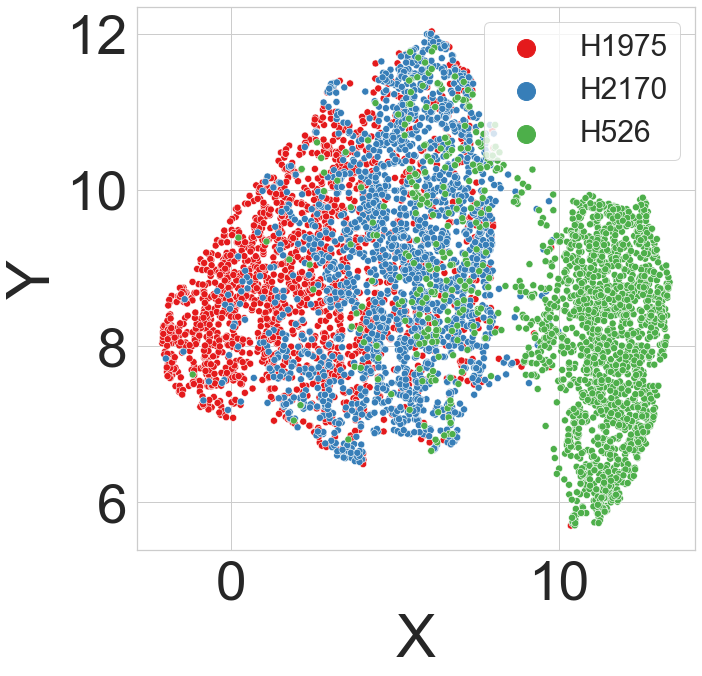

In [38]:
plt.figure(figsize=(10,10))
#plt.axis('off')
sns.set_style("whitegrid")

sns.scatterplot(data=df_F, x="X", y="Y", s=50, hue="ClassLabels1", palette=('Set1'))
plt.legend(markerscale=3, fontsize=30)

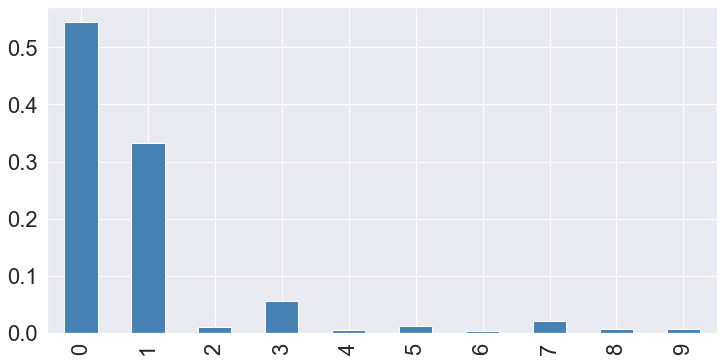

Accuracy: 0.8325


In [39]:
sns.set(font_scale=2)
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
import pandas as pd
plt.grid(None)

# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(mu_real_All, label1, test_size=0.2, random_state=1)
clf = DecisionTreeClassifier(criterion='gini', max_depth=7)
clf.fit(X_train, y_train)  # celltype
pd.Series(clf.feature_importances_, index=LatentZ.columns).plot.bar(color='steelblue', figsize=(12, 6))
plt.show()
y_pred = clf.predict(X_test)


print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

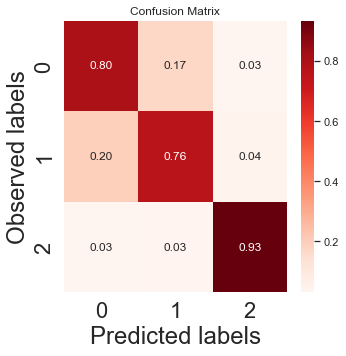

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix,plot_confusion_matrix
plt.figure(figsize=(5,5))
ax = plt.subplot()

sns.set(font_scale=1.0) # Adjust to fit
y_pred= clf.predict(X_test)

cm=confusion_matrix(y_test, y_pred)

df=pd.DataFrame(cm)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cmn, annot=True, fmt='.2f', ax=ax, cmap="Reds");  # annot=True to annotate cells

#plt.axis('off')

# labels, title and ticks
ax.set_xlabel('Predicted labels');
ax.set_ylabel('Observed labels');
ax.set_title('Confusion Matrix');
#ax.xaxis.set_ticklabels(label1);
#ax.yaxis.set_ticklabels(label1);


plt.show()

In [41]:
df_X = pd.DataFrame(mu_real_All)

df_z_scaled = df_X.copy()
for column in df_z_scaled.columns:
    df_z_scaled[column] = (df_z_scaled[column] - df_z_scaled[column].mean()) / (df_z_scaled[column].std())    
  

<AxesSubplot:>

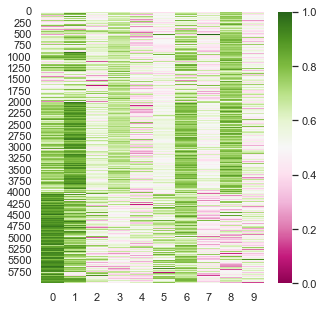

In [42]:
# copy the data
plt.figure(figsize=(5,5))

sns.set(font_scale = 1)


df_min_max_scaled = df_X.copy()
  
# apply normalization techniques
for column in df_min_max_scaled.columns:
    df_min_max_scaled[column] = (df_min_max_scaled[column] - df_min_max_scaled[column].min()) / (df_min_max_scaled[column].max() - df_min_max_scaled[column].min())    
sns.heatmap(df_min_max_scaled, cmap='PiYG')